Starte Live-Plot... (Strg+C zum Beenden)
RAW: 26.375
RAW: 26.3125
RAW: 26.3125
RAW: 26.5625
RAW: 27.6875
RAW: 28.5625
RAW: 29.25
RAW: 29.75
RAW: 30.125
RAW: 30.5
RAW: 30.75
RAW: 31.0
RAW: 31.1875
RAW: 31.375
RAW: 31.5
RAW: 31.6875
RAW: 31.8125
RAW: 31.875
RAW: 32.0
RAW: 32.0625
RAW: 32.1875
RAW: 32.25
RAW: 32.1875
RAW: 32.0
RAW: 31.875
RAW: 31.75
RAW: 31.5625
RAW: 31.4375
RAW: 31.3125
RAW: 31.1875
RAW: 31.0625
RAW: 30.9375
RAW: 30.8125
RAW: 30.75
RAW: 30.625
RAW: 30.5625
RAW: 30.4375
RAW: 30.375
RAW: 30.25
RAW: 85.0
RAW: 30.125
RAW: 30.0625
RAW: 30.0
RAW: 29.9375
RAW: 29.9375
RAW: 29.875
RAW: 30.0625
RAW: 30.0
RAW: 30.0
RAW: 29.9375
Beendet.


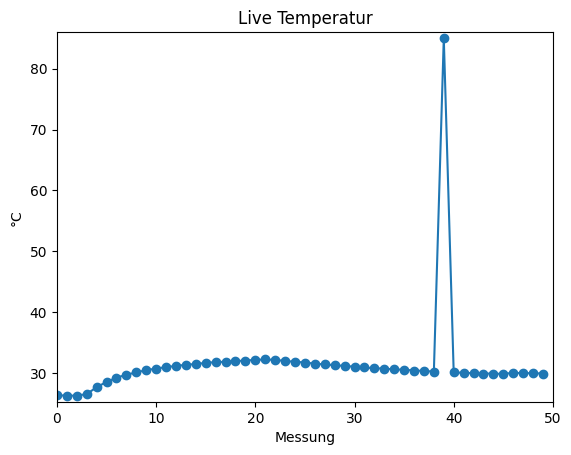

In [32]:
import subprocess
import sys
import matplotlib.pyplot as plt

PORT = "COM3"

cmd = [
    sys.executable, "-m", "mpremote",
    "connect", PORT,
    "run", "main.py"
]

proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    universal_newlines=True,
    bufsize=1
)

plt.ion()
fig, ax = plt.subplots()

temps = []

print("Starte Live-Plot... (Strg+C zum Beenden)")

try:
    while True:
        line = proc.stdout.readline()

        if not line:
            plt.pause(0.01)
            continue

        print("RAW:", line.strip())  # DEBUG

        try:
            temp = float(line.strip())
            temps.append(temp)

            # 👉 WICHTIG: Daten setzen
            ax.cla()
            ax.plot(range(len(temps)), temps, marker='o')

            ax.set_title("Live Temperatur")
            ax.set_ylabel("°C")
            ax.set_xlabel("Messung")

            # 👉 FIX: Achsen explizit setzen
            ax.set_xlim(0, max(10, len(temps)))
            ax.set_ylim(min(temps) - 1, max(temps) + 1)

            # 👉 zwingt Matplotlib zum Zeichnen
            fig.canvas.draw()
            fig.canvas.flush_events()

        except ValueError:
            pass

except KeyboardInterrupt:
    print("Beendet.")
    proc.terminate()